In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import hour
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from pyspark.ml.feature import VectorAssembler
import numpy as np
from sklearn.preprocessing import StandardScaler

spark = SparkSession.builder\
    .master("local[*]")\
    .appName("Accident")\
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

25/06/19 16:41:33 WARN Utils: Your hostname, bg-ubuntu resolves to a loopback address: 127.0.1.1; using 192.168.1.47 instead (on interface wlp0s20f3)
25/06/19 16:41:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/19 16:41:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
path = "file://" + os.path.abspath(os.path.join(os.getcwd(), "../../data/processed_accidents.parquet"))


df = spark.read.parquet(path)
df = df.withColumn("Hour", hour(df["Start_Time"]))
df.show(5, truncate=False)

+--------+-------------------+-------------------+---------+-----------+------------------+---------------+-----------+-----+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+----------------------+----------------------+-------------------------+-----------------------------+-------------------------+----------------------+-------------+------------+----------------------+----------------------+-------------------------+-----------------------------+-------------------------+----------------------+---------------+--------------------+----+
|Severity|Start_Time         |End_Time           |Start_Lat|Start_Lng  |Distance(mi)      |City           |County     |State|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressur

In [ ]:
scaler = StandardScaler()

def get_clusters(X,pca_num,clusterings):
  assembler = VectorAssembler(
      inputCols=X.columns,
      outputCol="features"
  )
  print("   Scaling",end="")
  X_scaled = scaler.fit_transform(np.array(assembler.transform(X).select("features").rdd.map(lambda row: row["features"]).collect()))
  X_pca = X_scaled
  if pca_num != None :
    print(",PCAing",end="")
    pca = PCA(n_components=pca_num)
    X_pca = pca.fit_transform(X_scaled)
  print(",kMeaning",end="")
  kmeans = KMeans(n_clusters=clusterings, random_state=42)
  clusters = kmeans.fit_predict(X_pca)
  print(" and Reversing")
  centers_pca = kmeans.cluster_centers_
  centers_scaled = centers_pca
  if pca_num != None:
    centers_scaled = pca.inverse_transform(centers_pca)
  centers_original = scaler.inverse_transform(centers_scaled)
  return X_pca, centers_pca, clusters , centers_original

In [4]:
def plot_data(data,centers,title,clusters):
  plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis')
  plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', label='Cluster Centers')
  plt.title(title)
  plt.show()

In [5]:
def transform_to_readable(array,cols):
  #round severity ?
  res = pd.DataFrame()
  for col in range(len(cols)):
    if '_indexed' in cols[col]:
      #how to find city (col == city)?
      res[cols[col][: - (len('_indexed'))]] = array[:,col].round()
    else:
      res[cols[col]] = array[:,col]
  return res

Start Clustering and Mapping Nbr 0/0:
 Start Clustering:
  -with Nbr PCA = 2, Nbr Cluster = 3
   Scaling

,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


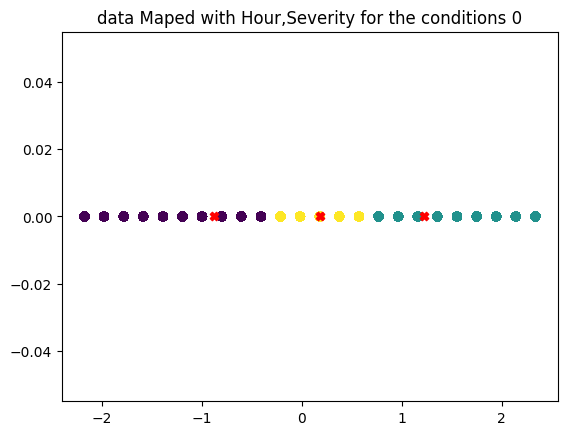

 Finished Mapping


,Hour,Severity
0,6.605225,1.0
1,17.323612,1.0
2,12.006276,1.0


Start Clustering and Mapping Nbr 0/2:
 Start Clustering:
  -with Nbr PCA = 2, Nbr Cluster = 3
   Scaling

In [ ]:
temp_data = None
temp_cluster = None
def get_all_clusters():
  first_features = []
  list_pca = [2,3,3]
  list_clustering = [3,3,5]
  following_feat = [[ 'Hour', 'Severity'],['Temperature(F)','Sunrise_Sunset_indexed'],['City_indexed','Visibility(mi)']]
  #all_occurence
  for i in range(len(list_pca)):
    first_features += following_feat[i]
    temp = df[first_features]
    databases = [temp[temp['Severity'] == 1],temp[temp['Severity'] == 5],temp]
    for j in range(3):
      if databases[j].count() > 0 :
        print("===========================================================================")
        print(f"Start Clustering and Mapping Nbr {i}/{j}:")
        print(" Start Clustering:")
        print(f"  -with Nbr PCA = {list_pca[i]}, Nbr Cluster = {list_clustering[i]}")
        data, data_center, data_cluster ,res_cluster = get_clusters(databases[j],list_pca[i],list_clustering[i])
        #display(data_cluster)
        #return data, data_cluster
        print(" Finished Clustering")
        print(" Start Mapping:")
        plot_data(data,data_center,f"data Maped with {','.join(first_features)} for the conditions {j}",data_cluster)
        print(" Finished Mapping")
        res_df = transform_to_readable(res_cluster,first_features)
        display(res_df)
        print("===========================================================================")
get_all_clusters()

In [ ]:
def get_answer_question():
  list_feat=[['Sunrise_Sunset_indexed','Severity'],['Weather_Condition_indexed', 'Severity'],['Severity','Amenity','Bump','Crossing','Give_Way','Junction','No_Exit','Railway','Roundabout','Station','Stop','Traffic_Calming','Traffic_Signal','Turning_Loop'],['Severity','Temperature(F)','Wind_Chill(F)','Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)']]
  list_question=['What type of Sunset/Twilight happened on a accident','What weather happened on a accident','On what type of road most accidents happened','On what atmospheric type most accidents happened']
  list_clustering = [3,3,5,5]
  list_pca = [None,None,10,4]
  #all_occurence
  for i in range(len(list_question)):
    temp = df[list_feat[i]]
    databases = [temp[temp['Severity'] == 1],temp[temp['Severity'] == 5],temp]
    for j in range(3):
      if databases[j].count() > 0 :
        print("===========================================================================")
        print(f"Start Clustering and Mapping Nbr {i}/{j}:")
        print(" Start Clustering:")
        data, data_center, data_cluster ,res_cluster = get_clusters(databases[j],list_pca[i],list_clustering[i])
        #display(data_cluster)
        #return data, data_cluster
        print(" Finished Clustering")
        print(" Start Mapping:")
        plot_data(data,data_center,f"data Maped in condition {j + 1} for '{list_question[i]}'",data_cluster)
        print(" Finished Mapping")
        res_df = transform_to_readable(res_cluster,list_feat[i])
        display(res_df)
        print("===========================================================================")
get_answer_question()